In [7]:
import pandas as pd
df_train = pd.read_csv('/kaggle/input/datasets/oddrationale/mnist-in-csv/mnist_train.csv')
df_test = pd.read_csv('/kaggle/input/datasets/oddrationale/mnist-in-csv/mnist_test.csv')
print(df_train.shape)
print(df_test.shape)

(60000, 785)
(10000, 785)


<font color = 'red' size = 5>Ready the Data</font>

In [8]:
X_train = df_train.drop("label", axis=1)  #data
y_train = df_train["label"] #target

X_test = df_test.drop("label", axis=1) #test data
y_test = df_test["label"] #test target

<font color = 'orange' size = 5>Preprocessing</font>

In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

<font color = 'yellow' size = 5>Trainig SVM</font>

In [10]:
from cuml.svm import SVC as cuSVC
import cupy as cp

X_train_gpu = cp.asarray(X_train_scaled)
y_train_gpu = cp.asarray(y_train.values)

svm_model = cuSVC(kernel="rbf", C=5, gamma="scale")
svm_model.fit(X_train_gpu, y_train_gpu)

SVC()

<font size = 5 color ='lightgreen'>Predictions</font>

In [14]:
#Accuracy: Overall percentage of correct predictions.
from sklearn.metrics import accuracy_score
y_pred = svm_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.973


In [18]:
#Confusion Matrix: Provides a breakdown of correct/incorrect predictions for each digit.
#Some GPU CPU Tricks
# Convert test data to GPU
X_test_gpu = cp.asarray(X_test_scaled)

# Predict on GPU
y_pred_gpu = svm_model.predict(X_test_gpu)

# Move predictions back to CPU (NumPy)
y_pred = cp.asnumpy(y_pred_gpu)
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 966    0    3    2    1    2    3    1    2    0]
 [   0 1127    3    0    0    1    2    1    1    0]
 [   3    2 1001    1    1    0    1   13    9    1]
 [   0    0    2  987    0    7    0    7    5    2]
 [   0    0    9    0  950    2    3    7    2    9]
 [   2    0    1    7    2  863    4    5    5    3]
 [   3    2    2    0    3    7  935    2    4    0]
 [   0    5    8    2    0    1    0 1002    0   10]
 [   2    0    3    4    3   11    2    9  936    4]
 [   1    3    3    8    9    4    0   14    4  963]]


In [19]:
#Confusion Matrix: Provides a breakdown of correct/incorrect predictions for each digit.
from sklearn.metrics import classification_report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.97      0.97      1032
           3       0.98      0.98      0.98      1010
           4       0.98      0.97      0.97       982
           5       0.96      0.97      0.96       892
           6       0.98      0.98      0.98       958
           7       0.94      0.97      0.96      1028
           8       0.97      0.96      0.96       974
           9       0.97      0.95      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



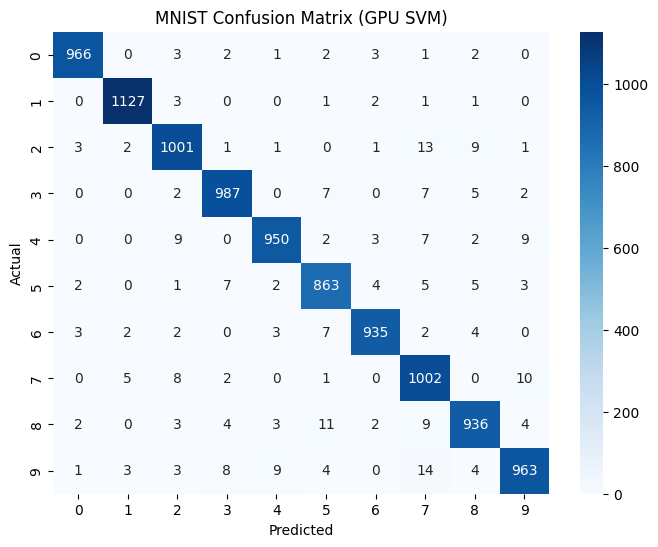

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MNIST Confusion Matrix (GPU SVM)")
plt.show()
